# $\text{Taller - Regresión Lineal Múltiple}$
## $\text{Efectos del Consumo de Alcohol en el Rendimiento Estudiantil}$


---

## **$\text{Tabla de contenido:}$**
0. $\text{Importar Librerías}$
1. $\text{Regresión Lineal Múltiple}$
2. $\text{Comprendiendo los Datos}$
3. $\text{Limpieza de Datos}$
4. $\text{Análisis Exploratorio de Datos (EDA)}$
5. $\text{Preparación de Variables (X e y)}$
6. $\text{División de los Datos en Conjuntos de Entrenamiento y Prueba}$
7. $\text{Entrenamiento del Modelo de Regresión Lineal Múltiple}$
8. $\text{Cálculo de Coeficientes y Evaluación del Modelo}$

9. $\text{Entrenamiento con SVR}$

---

## $\text{0. Importar Librerías}$

In [ ]:
# Importar las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.svm import SVR

## $\text{1. Regresión Lineal Múltiple}$
La regresión lineal múltiple es una extensión de la regresión lineal simple, donde se utilizan múltiples variables independientes para predecir el valor de una variable dependiente. En este caso, exploraremos cómo factores como el consumo de alcohol y otros datos demográficos afectan el rendimiento académico de los estudiantes.

## $\text{2. Comprendiendo los Datos}$


### $\text{Descripción del Dataset}$
En este análisis, usaremos el dataset "Effects of Alcohol on Student Performance" que contiene información sobre el rendimiento académico de estudiantes y sus hábitos de consumo de alcohol, así como otras características demográficas y de comportamiento. Las variables en este dataset incluyen:

**Columnas y Descripción:**

* `marca_tiempo`: Marca temporal de la respuesta (se eliminará por no aportar información relevante para el análisis).
* `sexo`: Género del estudiante (variable categórica).
* `promedio_matricula`: Promedio académico del último año.
* `año_anterior`: Año académico anterior en el que se matriculó el estudiante.
* `facultad`: Facultad en la que está matriculado el estudiante (variable categórica).
* `promedio_2023`: Promedio de notas en el año 2023, que será nuestra variable dependiente para evaluar el rendimiento académico.
* `alojamiento_2023`: Tipo de alojamiento del estudiante en 2023 (casa de los padres, residencia universitaria, etc.).
* `mesada_2023`: Cantidad mensual recibida por el estudiante.
* `beca_2023`: Si el estudiante tiene beca en 2023 (variable categórica).
* `horas_estudio`: Horas promedio que el estudiante dedica al estudio semanalmente.
* `frecuencia_social`: Frecuencia con la que el estudiante socializa.
* `bebidas_por_salida`: Cantidad promedio de bebidas alcohólicas consumidas en una salida social.
* `clases_perdidas`: Número de clases perdidas en el semestre.
* `modulos_reprobados`: Número de módulos reprobados en el semestre.
* `estado_romantico`: Estado de relación romántica (variable categórica).
* `padres_aprueban`: Percepción del estudiante sobre la aprobación de sus padres respecto a su consumo de alcohol.
`relacion_padres`: Calidad de la relación con sus padres (variable categórica).


**Cargue** el archivo CSV "Effects of Alcohol on Student Performance.csv" y realice un análisis inicial para entender las columnas y el tipo de datos que contiene.

In [ ]:
# Cargar el dataset y ver las primeras filas
data = pd.read_csv('Effects of Alcohol on Student Performance.csv')
data.head()

,Timestamp,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


**Pregunta orientadora:** ¿Cuántas variables crees que podrían ser significativas para predecir el rendimiento académico?

## $\text{3. Limpieza de Datos}$
1. Detección de **valores nulos**: Identificar y manejar valores faltantes.
2. Conversión de **tipos de datos**: Asegurarse de que las columnas están en los tipos de datos correctos.
3. Codificación de **variables categóricas**: Convertir variables categóricas en numéricas si es necesario para el modelo de regresión.

In [ ]:
# Revisar si hay valores faltantes
data.isnull().sum()

,0
Timestamp,0
Your Sex?,2
Your Matric (grade 12) Average/ GPA (in %),7
What year were you in last year (2023) ?,73
What faculty does your degree fall under?,7
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),86
Your Accommodation Status Last Year (2023),23
Monthly Allowance in 2023,31
Were you on scholarship/bursary in 2023?,8
Additional amount of studying (in hrs) per week,3


In [ ]:
# Para facilitar la lectura de las columnas por ser demasido largas cambiar sus nombres

# Renombrar columnas en español (o inglés)
data.columns = [
    'marca_tiempo', 'sexo', 'promedio_matricula', 'año_anterior', 'facultad',
    'promedio_2023', 'alojamiento_2023', 'mesada_2023', 'beca_2023',
    'horas_estudio', 'frecuencia_social', 'bebidas_por_salida', 'clases_perdidas',
    'modulos_reprobados', 'estado_romantico', 'padres_aprueban', 'relacion_padres'
]

In [ ]:
# Revisar el tipo de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   marca_tiempo        406 non-null    object 
 1   sexo                404 non-null    object 
 2   promedio_matricula  399 non-null    float64
 3   año_anterior        333 non-null    object 
 4   facultad            399 non-null    object 
 5   promedio_2023       320 non-null    float64
 6   alojamiento_2023    383 non-null    object 
 7   mesada_2023         375 non-null    object 
 8   beca_2023           398 non-null    object 
 9   horas_estudio       403 non-null    object 
 10  frecuencia_social   404 non-null    object 
 11  bebidas_por_salida  404 non-null    object 
 12  clases_perdidas     403 non-null    object 
 13  modulos_reprobados  403 non-null    object 
 14  estado_romantico    403 non-null    object 
 15  padres_aprueban     402 non-null    object 
 16  relacion

In [ ]:
# Llenar valores faltantes con '0' para columnas específicas de tipo string y 0 para las float
data['año_anterior'] = data['año_anterior'].fillna('0')
data['promedio_2023'] = data['promedio_2023'].fillna(0)
data['mesada_2023'] = data['mesada_2023'].fillna('0')

# Imputar la moda en columnas categóricas con pocos valores faltantes
data['sexo'] = data['sexo'].fillna(data['sexo'].mode()[0])
data['facultad'] = data['facultad'].fillna(data['facultad'].mode()[0])
data['beca_2023'] = data['beca_2023'].fillna(data['beca_2023'].mode()[0])
data['horas_estudio'] = data['horas_estudio'].fillna(data['horas_estudio'].mode()[0])
data['frecuencia_social'] = data['frecuencia_social'].fillna(data['frecuencia_social'].mode()[0])
data['bebidas_por_salida'] = data['bebidas_por_salida'].fillna(data['bebidas_por_salida'].mode()[0])
data['clases_perdidas'] = data['clases_perdidas'].fillna(data['clases_perdidas'].mode()[0])
data['modulos_reprobados'] = data['modulos_reprobados'].fillna(data['modulos_reprobados'].mode()[0])
data['estado_romantico'] = data['estado_romantico'].fillna(data['estado_romantico'].mode()[0])
data['padres_aprueban'] = data['padres_aprueban'].fillna(data['padres_aprueban'].mode()[0])
data['relacion_padres'] = data['relacion_padres'].fillna(data['relacion_padres'].mode()[0])
data['alojamiento_2023'] = data['alojamiento_2023'].fillna(data['alojamiento_2023'].mode()[0])

# # Calcular la media de la columna 'promedio_2023', ignorando los valores 0
# mean_value = data[data['promedio_2023'] != 0]['promedio_2023'].mean()

# # Reemplazar los valores 0 por la media calculada
# data['promedio_2023'] = data['promedio_2023'].replace(0, mean_value)

In [ ]:
# Revisar qué columnas siguen teniendo valores faltantes
data.isnull().sum()

,0
marca_tiempo,0
sexo,0
promedio_matricula,7
año_anterior,0
facultad,0
promedio_2023,0
alojamiento_2023,0
mesada_2023,0
beca_2023,0
horas_estudio,0


In [ ]:
# Ahora imputar el promedio matricula con el promedio

promedio_matricula = data['promedio_matricula'].mean()
data['promedio_matricula'] = data['promedio_matricula'].fillna(promedio_matricula)

In [ ]:
# Eliminar columna de marca de tiempo
data = data.drop('marca_tiempo', axis=1)

In [ ]:
# Ahora sí, se verifica que no hayan valores faltantes
data.isnull().sum()

,0
sexo,0
promedio_matricula,0
año_anterior,0
facultad,0
promedio_2023,0
alojamiento_2023,0
mesada_2023,0
beca_2023,0
horas_estudio,0
frecuencia_social,0


In [ ]:
# Obtener los valores únicos de cada columna para entender mejor cómo manejar las conversiones
for col in data.columns:
    print(f"Valores únicos de la columna '{col}':")
    print(data[col].unique())
    print("="*50)


Valores únicos de la columna 'sexo':
['Female' 'Male']
Valores únicos de la columna 'promedio_matricula':
[76.         89.         74.         83.         80.         85.
 75.         79.         72.         78.         87.         86.
 69.         73.         84.         99.         82.6        65.
 81.         88.         70.         98.         90.         98.33
 77.98972431 82.         77.         68.         66.         92.
 91.86       71.         63.         67.         60.         94.
 95.         34.         86.4        95.5        55.         91.21
 96.         64.        ]
Valores únicos de la columna 'año_anterior':
['2nd Year' '1st Year' '0' '3rd Year' '4th Year' 'Postgraduate']
Valores únicos de la columna 'facultad':
['Arts & Social Sciences' 'Economic & Management Sciences' 'AgriSciences'
 'Engineering' 'Science' 'Medicine and Health Services' 'Law' 'Education']
Valores únicos de la columna 'promedio_2023':
[72.   75.   55.   84.   52.    0.   54.   64.   76.   65.   62

## $\text{4. Análisis Exploratorio de Datos (EDA)}$
Realizar un análisis exploratorio para identificar patrones entre las variables. Aquí usaremos visualizaciones para entender las relaciones entre las características y la variable de rendimiento académico.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


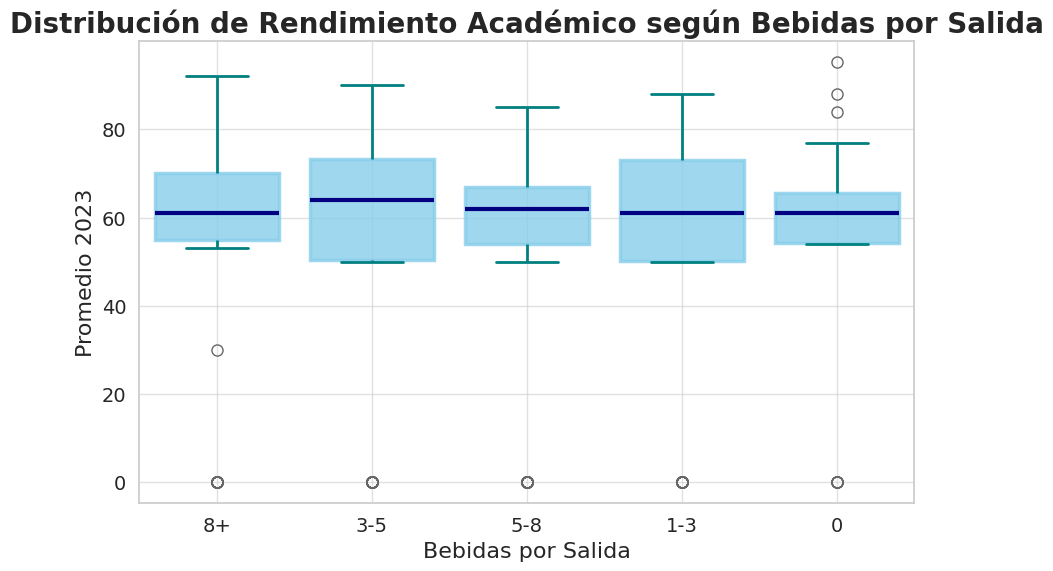

<ipython-input-12-d1cd6c2c60a6>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='clases_perdidas', y='promedio_2023', data=data, errorbar=None,


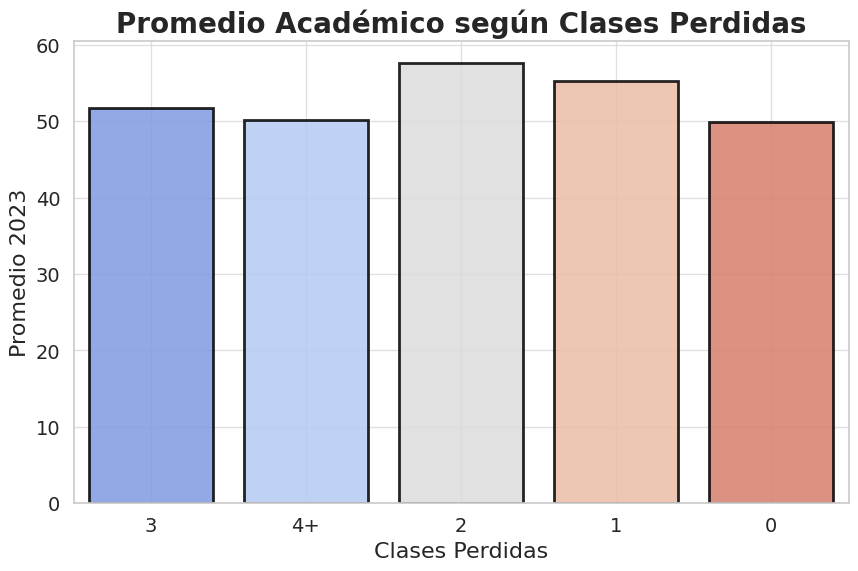

In [ ]:
# Configuración general del estilo
sns.set(style="whitegrid", palette="coolwarm")  # Usando una paleta de colores más llamativa

# Función para configurar el gráfico
def stylize_plot(title, xlabel, ylabel):
    plt.title(title, fontsize=20, fontweight='bold')  # Título más grande y en negrita
    plt.xlabel(xlabel, fontsize=16)  # Etiqueta en los ejes más grande
    plt.ylabel(ylabel, fontsize=16)  # Etiqueta en los ejes más grande
    plt.grid(True, alpha=0.6)  # Grilla con transparencia
    plt.xticks(fontsize=14)  # Ejes X con texto más grande
    plt.yticks(fontsize=14)  # Ejes Y con texto más grande

# Gráfico de cajas para `bebidas_por_salida`
plt.figure(figsize=(10, 6))
sns.boxplot(x='bebidas_por_salida', y='promedio_2023', data=data,
            linewidth=2.5, fliersize=8,
            boxprops=dict(alpha=0.8, color="skyblue"),  # Caja con color
            medianprops=dict(color="navy", linewidth=3),  # Línea de la mediana más gruesa
            whiskerprops=dict(linewidth=2, color="teal"),  # Bigotes más gruesos
            capprops=dict(linewidth=2, color="teal"))  # Líneas de los extremos más gruesas
stylize_plot("Distribución de Rendimiento Académico según Bebidas por Salida",
             "Bebidas por Salida", "Promedio 2023")
plt.show()

# Gráfico de barras para `clases_perdidas`
plt.figure(figsize=(10, 6))
sns.barplot(x='clases_perdidas', y='promedio_2023', data=data, errorbar=None,
            edgecolor="black", linewidth=2,  # Borde más grueso
            palette="coolwarm",  # Usando la paleta de colores
            alpha=0.85)  # Opacidad ajustada
stylize_plot("Promedio Académico según Clases Perdidas",
             "Clases Perdidas", "Promedio 2023")
plt.show()

## $\text{5. Preparación de Variables (X e y)}$
Seleccionar las variables independientes (X) y la variable dependiente (y) a partir del análisis previo.

In [ ]:
# Separación usando slicing con iloc
X = data.iloc[:, :4].join(data.iloc[:, 5:], how='left').values  # Independientes
y = data.iloc[:, 4].values  # Dependiente

In [ ]:
# Hacer column Transform a las variables categóricas donde No existen relaciones de orden

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(sparse_output=False), [2, 3,5,7,8,9,10,11,14])], remainder = 'passthrough')

X_onehot = ct.fit_transform(X)

#Llamamos X onehot a nuestra nueva variale X con las variables categóricas
print(X_onehot)

[[0.0 0.0 1.0 ... 'No' 'Yes' 'Yes']
 [0.0 0.0 1.0 ... 'Yes (NSFAS, etc...)' 'No' 'Yes']
 [0.0 1.0 0.0 ... 'No' 'No' 'Yes']
 ...
 [0.0 1.0 0.0 ... 'No' 'No' 'Yes']
 [1.0 0.0 0.0 ... 'No' 'No' 'Yes']
 [0.0 1.0 0.0 ... 'No' 'No' 'No']]


In [ ]:
# Imprimir la 1era fila del X_onehot, para ver el índice de las columnas binarias
X_onehot[:][0]

array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
       1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 'Female',
       76.0, 'Private accommodation/ stay with family/friends', 'No',
       'Yes', 'Yes'], dtype=object)

In [ ]:
# Hacer la lista de los índices de las columnas con valores binarios
binary_columns = [-1,  -2, -3, -4, -6]

# Procesar cada columna binaria y reemplazarlas en X_onehot
for col in binary_columns:
    lb = LabelBinarizer()
    binarized_column = lb.fit_transform(X_onehot[:, col])  # Convertimos la columna a binaria
    X_onehot[:, col] = binarized_column.flatten()  # Reemplazamos en el array original

In [ ]:
# Imprimimos el resultado después del Onehoy el LabelBinarizer
print(X_onehot)

[[0.0 0.0 1.0 ... 0 1 1]
 [0.0 0.0 1.0 ... 1 0 1]
 [0.0 1.0 0.0 ... 0 0 1]
 ...
 [0.0 1.0 0.0 ... 0 0 1]
 [1.0 0.0 0.0 ... 0 0 1]
 [0.0 1.0 0.0 ... 0 0 0]]


In [ ]:
# Imprimir los tamaños
print(X_onehot.shape, y.shape)

(406, 56) (406,)


## $\text{6. División de los Datos en Conjuntos de Entrenamiento y Prueba}$
Dividir el dataset en un conjunto de entrenamiento y uno de prueba para evaluar el modelo de manera justa.

In [ ]:
# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_onehot, y,
                                                    test_size=0.2, random_state=47)


## $\text{7. Entrenamiento del Modelo de Regresión Lineal Múltiple}$
Entrenar el modelo de regresión lineal múltiple con el conjunto de entrenamiento.

In [ ]:
# Crear y entrenar el modelo de regresión lineal múltiple
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## $\text{8. Cálculo de Coeficientes y Evaluación del Modelo}$
Obtener los coeficientes del modelo y evaluarlo utilizando el error cuadrático medio (MSE) y el coeficiente de determinación ($R^2$).

In [ ]:
# Obtener los coeficientes
print("Intercepto (b0):", model.intercept_)
print("\n Coeficientes (b1..bn):", model.coef_)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n Error cuadrático medio (MSE): {mse}")
print(f"\nCoeficiente de determinación (R^2): {r2}")


Intercepto (b0): 29.13038113206876

 Coeficientes (b1..bn): [-5.59131730e+01  7.53316288e+00  1.15307217e+01  1.17458743e+01
  1.74348714e+01  7.66854280e+00 -4.31882750e+00 -3.47852903e+00
 -1.44772351e+00  1.06605708e+01 -3.15968902e+00 -3.02348615e+00
  4.21243764e+00  5.55246739e-01 -1.80381651e+00 -7.84388224e-01
 -8.62135220e-02  2.22790719e+00 -1.19107553e+00  1.63758659e+00
  4.08358156e+00 -1.55954421e+00  5.49968678e-02 -2.58472663e+00
  5.69242326e-03  4.35569491e+00  2.45294187e-01 -4.35042850e+00
  1.14102376e+00 -4.54514693e-01 -9.37069671e-01 -3.99137483e-01
  3.89107866e-01 -8.55884680e-01 -1.53075355e-01  1.01898965e+00
 -7.98690165e-01  1.39348983e+00  1.34554145e+00  1.28606468e+00
 -3.22640579e+00  5.83833221e+00  1.03483352e+00 -1.82717689e+00
 -2.03704276e+00 -3.00894607e+00 -6.84711110e+00  1.81002523e+01
 -4.76888082e+00 -6.48426040e+00  2.12338106e+00  2.98518300e-01
  4.08563496e+00  1.23417653e+00  8.44092529e-01  2.01834025e+00]

 Error cuadrático medio (MSE

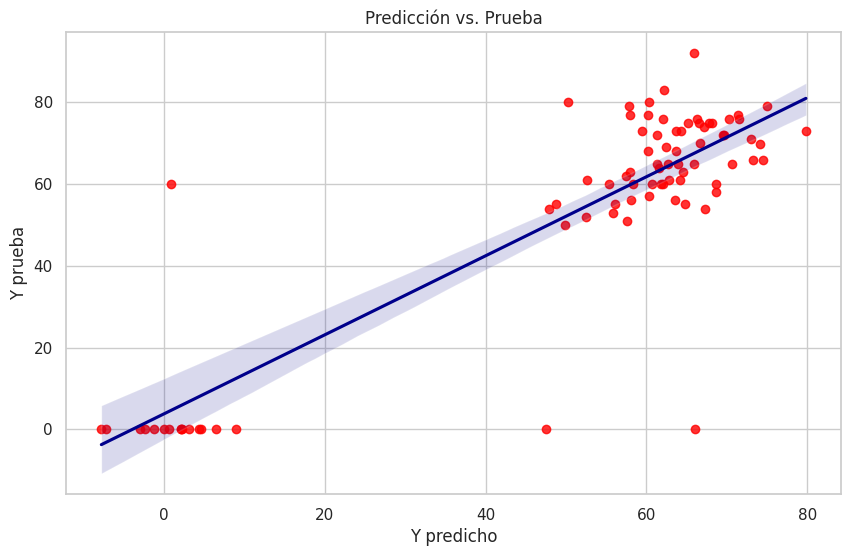

In [ ]:
# Comparar predicciones con valores reales en el gráfico

plt.figure(figsize=(10, 6))
sns.regplot(x=y_pred, y=y_test, scatter_kws={'color': 'red'}, line_kws={'color': 'darkblue'})


plt.xlabel('Y predicho')
plt.ylabel('Y prueba')
plt.title('Predicción vs. Prueba')
plt.show()

## $\text{9. Entrenamiento con SVR}$

Entrene un modelo de SVR y decida cuál de los modelos es mejor basado en alguna métrica de "goodness of fit". Muestre el scatter plot de los valores predichos vs valores de prueba para ver qué tan bien se ajusta cada modelo.

Recuerde que para usar SVR debe **escalar** los datos...

In [ ]:
X_train[0]

array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0,
       0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1, 72.0, 1,
       1, 0, 1], dtype=object)

In [ ]:
y_train[:4]

array([60., 60., 30., 65.])

In [ ]:
# Instancio el objeto scaler solo para las x

sc_x = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Ajusta el escalador en la columna -5 del conjunto de entrenamiento y transforma
X_train_sc[:, -5] = sc_x.fit_transform(X_train[:, -5].reshape(-1, 1)).flatten()

# Transforma la columna -5 del conjunto de prueba utilizando el mismo escalador
X_test_sc[:, -5] = sc_x.transform(X_test[:, -5].reshape(-1, 1)).flatten()

In [ ]:
print('X_train: \n', X_train[0][:], '\n') #se corrobora la estandarización
print('X_test: \n', X_test[0][:],'\n')

print('X_train_sc: \n', X_train_sc[0][:], '\n') #se corrobora la estandarización
print('X_test_sc: \n', X_test_sc[0][:])

X_train: 
 [0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0
 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1 72.0 1 1 0 1] 

X_test: 
 [0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0
 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0
 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0 67.0 1 0 0 1] 

X_train_sc: 
 [0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0
 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1
 -0.8377431988967146 1 1 0 1] 

X_test_sc: 
 [0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0
 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0
 0.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0
 -1.5318535192804141 1 0 0 1]


In [ ]:
#Se instancia el objeto SOLO para las Y
sc_y = StandardScaler()

y_train_sc = sc_y.fit_transform(y_train.reshape(-1,1))
y_test_sc = sc_y.transform(y_test.reshape(-1,1))

In [ ]:
print('y_train: \n', y_train[0:5], '\n') #se corrobora la estandarización
print('y_test: \n', y_test[0:5],'\n')

print('y_train_sc: \n', y_train_sc[0:2], '\n') #se corrobora la estandarización
print('y_test_sc: \n', y_test_sc[0:2])

y_train: 
 [60. 60. 30. 65. 54.] 

y_test: 
 [80. 60. 60. 75. 62.] 

y_train_sc: 
 [[0.28154101]
 [0.28154101]] 

y_test_sc: 
 [[0.98927349]
 [0.28154101]]


In [ ]:
# Instanciar el modelo SVR
modelo_svr = SVR()  #se puede ajustar otros parámetros según las necesidades kernel = 'linear' kernel = 'sigmoid'

y_train_sc = np.reshape(y_train_sc, (len(y_train_sc), ))

#Se entrena el modelo
modelo_svr.fit(X_train_sc, y_train_sc)

SVR()

In [ ]:
y_pred_svr = modelo_svr.predict(X_test_sc) #predicción del modelo SVR
print(y_pred_svr[0:5])

[ 0.543768   -1.3949328   0.49750056  0.7436691   0.33374354]


In [ ]:
#Ver la escala del Y_pred y y_test
print('y_pred_SVR: ', min(y_pred_svr), max(y_pred_svr), '\n')
print('y_test_SVR: ', min(y_test_sc), max(y_test_sc), '\n')

y_pred_SVR:  -1.9766894827084807 0.7890966856199209 

y_test_SVR:  [-1.84165645] [1.41391298] 



In [ ]:
#Métrica de desepeño R2

r2_svr = r2_score(y_test_sc, y_pred_svr)
print(f'El coeficiente de determinación R2 es = {r2_svr} ')

El coeficiente de determinación R2 es = 0.7447444174121477 


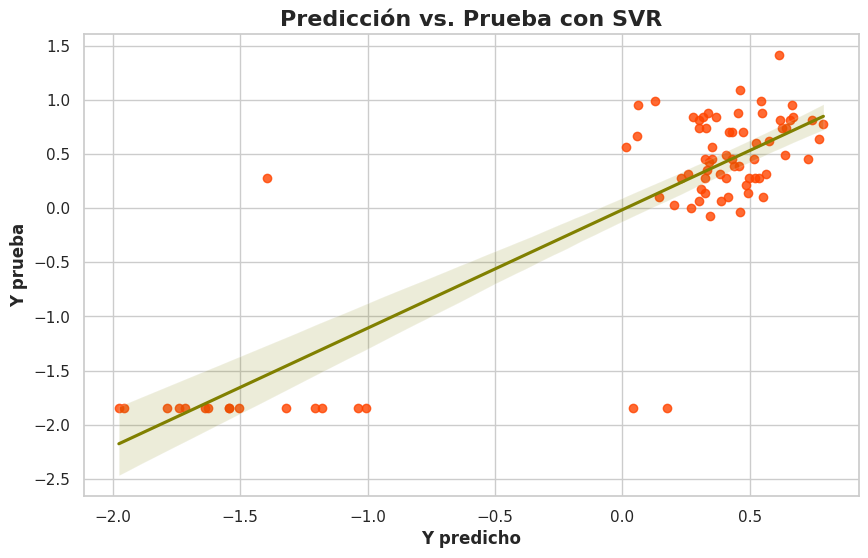

In [ ]:
#Gráfico y Predicción vs. y Prueba

plt.figure(figsize=(10, 6))
sns.regplot(x=y_pred_svr, y=y_test_sc, scatter_kws={'color': 'orangered'}, line_kws={'color': 'olive'})

#plt.plot([0, 1], [0, 1], '--', color= 'purple', linewidth=3.0)
plt.xlabel('Y predicho', fontweight='bold')
plt.ylabel('Y prueba', fontweight='bold')
plt.title('Predicción vs. Prueba con SVR', fontsize=16, fontweight='bold')
# plt.xlim(-1.2, 3)
# plt.ylim(-1.2, 3.5)
plt.show()

In [ ]:
# Comparar los dos r_2

print('¿Cuál de los dos modelos es mejor?: \n\n * LR: ', r2 , '\n * SVR: ', r2_svr)

¿Cuál de los dos modelos es mejor?: 

 * LR:  0.751329224070985 
 * SVR:  0.7447444174121477
